In [141]:
import torch
import torch.nn as nn
from torchvision.datasets import Flowers102
import matplotlib.pyplot as plt
from torchvision import transforms
import numpy as np
from torch.utils.data import DataLoader
import torch.optim as optim 

In [142]:
train_transform=transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(0.2,0.3,0.3,0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
"""
No random ness in test/val data so removed
Randomresized crop-. crops randomly
Random horizontal flip
Color jitter -> changes one factor randomly
"""

'\nNo random ness in test/val data so removed\nRandomresized crop-. crops randomly\nRandom horizontal flip\nColor jitter -> changes one factor randomly\n'

In [143]:
train_ds=Flowers102(root="data",split="train",download=True,transform=train_transform)
val_ds=Flowers102(root="data",split="val",download=True,transform=val_transform)
test_ds=Flowers102(root="data",split="test",download=True,transform=val_transform)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3130406..1.8208281].


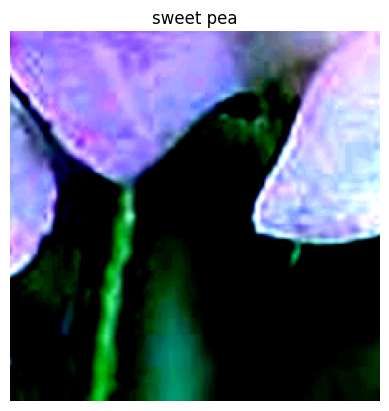

In [144]:
image,label=train_ds[30]
plt.imshow(image.permute(1, 2, 0))
plt.title(train_ds.classes[label])
plt.axis("off")
plt.show()

In [145]:
### data Loader
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

In [146]:
### Model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 102)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [147]:
### traininf setup
model=CNN()
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=1e-3)

In [148]:
def train():
    total_loss=0
    model.train()
    for image,label in train_loader:
        optimizer.zero_grad() 
        predict=model(image)
        loss_ca=criterion(predict,label)
        total_loss+=loss_ca
        loss_ca.backward()
        optimizer.step()
    return total_loss/len(train_loader)    

In [149]:
def evaluate(loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [150]:
epochs = 10

for epoch in range(epochs):
    train_loss = train()
    val_acc = evaluate(val_loader)

    print(f"Epoch {epoch+1}")
    print(f"Loss: {train_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

Epoch 1
Loss: 4.5297
Val Accuracy: 0.0765
Epoch 2
Loss: 4.1115
Val Accuracy: 0.0971
Epoch 3
Loss: 3.9267
Val Accuracy: 0.1255
Epoch 4
Loss: 3.7871
Val Accuracy: 0.1441
Epoch 5
Loss: 3.6997
Val Accuracy: 0.2010
Epoch 6
Loss: 3.5798
Val Accuracy: 0.2010
Epoch 7
Loss: 3.5242
Val Accuracy: 0.1843
Epoch 8
Loss: 3.4006
Val Accuracy: 0.2275
Epoch 9
Loss: 3.3956
Val Accuracy: 0.2353
Epoch 10
Loss: 3.3523
Val Accuracy: 0.2304


In [ ]:
"""
Epoch 10
Loss: 3.3523
Val Accuracy: 0.2304
Not bad considering our CNN is very small and FLOWER102 is a very strong dataset.
"""